## Group Members:

### Hifza Haleem (SP22-BAI-019)
### Saad Ibrar (SP22-BAI-041)
### Muhammad Haris (SP22-BAI-027)

># **` Pixel Locator `**




---



---








In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Selection

## Kaggle Images Dataset

The dataset used for this analysis was sourced from Kaggle. The dataset, available at the following Kaggle link [Images Dataset](https://www.kaggle.com/datasets/pavansanagapati/images-dataset/), consists of images belonging to various categories such as bikes, cars, cats, dogs, flowers, horses, and humans.

### Dataset Description:

- **Categories:**
  - Bike
  - Cars
  - Cats
  - Dogs
  - Flowers
  - Horses
  - Human


### Note:
The dataset and its associated details can be found on the Kaggle platform. Appropriate credit and acknowledgment go to the original data provider: [Kaggle Images Dataset](https://www.kaggle.com/datasets/pavansanagapati/images-dataset/).



### Data Pre-processing and Initial Analysis:

The images were pre-processed using standard techniques, including grayscale conversion, resizing, flattening, feature scaling, removing outliers using z-score, and padding arrays to a fixed size.

1. **Grayscale Conversion:** Images were converted to grayscale to simplify analysis.
2. **Resizing:** All images were resized to a uniform size of 256x256 pixels.
3. **Flattening:** The pixel arrays of resized images were flattened for further processing.
4. **Feature Scaling:** Pixel values were scaled to a range between 0 and 1.
5. **Outlier Removal:** Outliers were removed using z-score to enhance data quality.
6. **Array Padding:** The arrays were padded to a fixed size of 65536.

After pre-processing, we created a DataFrame containing the pre-processed image data and corresponding categories. The initial analysis includes visualizations such as:

- **Number of Samples in Each Category:** Displayed a countplot to show the distribution of samples across categories.
- **Sample Images from Each Category:** Showcased sample images from different categories.
- **Distribution of Mean Pixel Values:** Plotted a histogram to visualize the distribution of mean pixel values across all images.

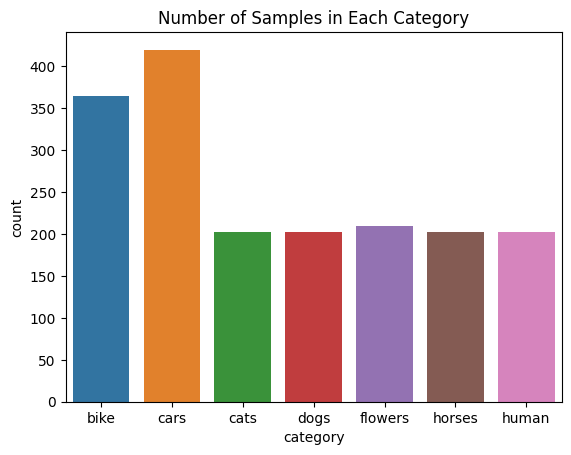

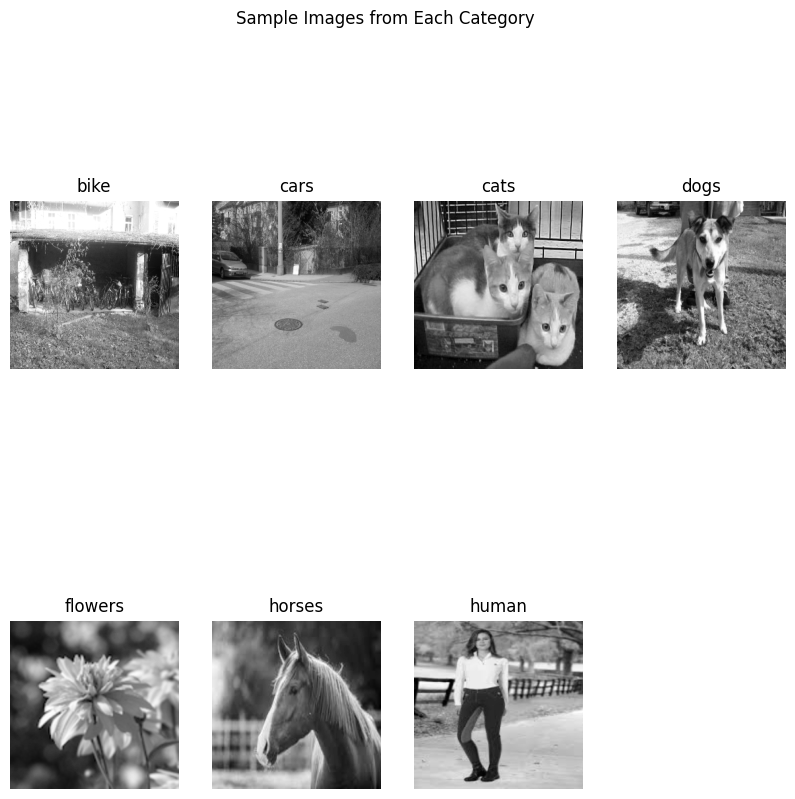

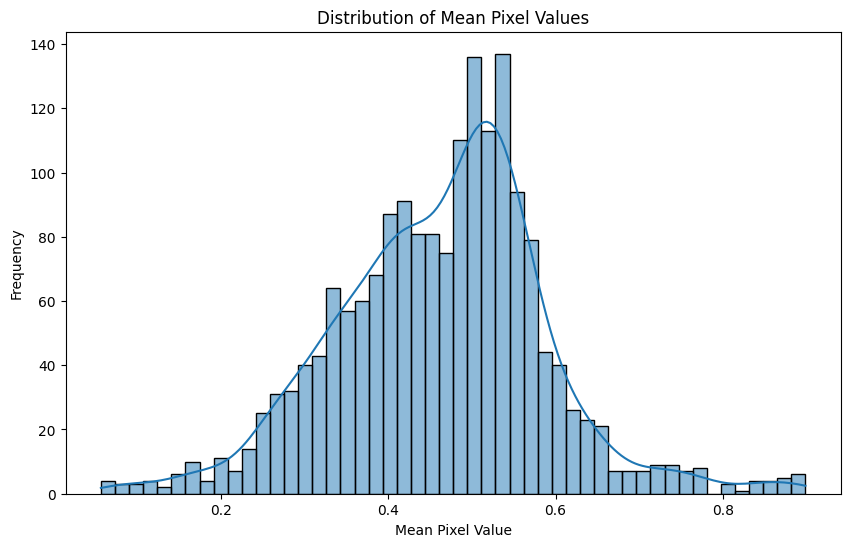

In [ ]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore

# Function for data pre-processing on all images in each folder
def preprocess_images(root_path, categories):
    all_data = []

    for category in categories:
        category_path = os.path.join(root_path, category)

        # Process each image in the category
        for image_filename in os.listdir(category_path):
            image_path = os.path.join(category_path, image_filename)
            original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale

            # Apply pre-processing steps
            resized_image = cv2.resize(original_image, (256, 256))
            flattened_image = resized_image.flatten()  # Flatten the image array

            # Feature scaling
            scaled_image = flattened_image / 255.0

            # Remove outliers using z-score
            z_scores = zscore(scaled_image)
            abs_z_scores = np.abs(z_scores)
            threshold = 3  # Set your desired threshold
            no_outliers = scaled_image[(abs_z_scores < threshold)]

            # Pad the array to a fixed size (e.g., 65536)
            padded_array = np.pad(no_outliers, (0, 65536 - len(no_outliers)))

            # Store pre-processed data
            all_data.append((padded_array, category))

    return all_data

root_path = "/content/drive/MyDrive/"
categories = ["bike", "cars", "cats", "dogs", "flowers", "horses", "human"]

# Perform data pre-processing on all images in each folder without displaying images
all_data = preprocess_images(root_path, categories)

# Assuming each element in all_data is a tuple (image_data, category)
data_dict = {'data': [item[0] for item in all_data], 'category': [item[1] for item in all_data]}
df = pd.DataFrame(data_dict)

# Display the number of samples in each category
sns.countplot(x='category', data=df)
plt.title('Number of Samples in Each Category')
plt.show()

# Display a sample image from each category
unique_categories = df['category'].unique()  # Get unique categories from the DataFrame
plt.figure(figsize=(10, 10))
for i, category in enumerate(unique_categories):
    plt.subplot(2, 4, i + 1)
    plt.imshow(df[df['category'] == category]['data'].iloc[0].reshape(256, 256), cmap='gray')
    plt.title(category)
    plt.axis('off')
plt.suptitle('Sample Images from Each Category')
plt.show()

# Display distribution of pixel values
plt.figure(figsize=(10, 6))
sns.histplot(df['data'].apply(lambda x: x.mean()), bins=50, kde=True)
plt.title('Distribution of Mean Pixel Values')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frequency')
plt.show()

## Results and Findings of Data Preprocessing and initial Analysis:



### *   Number of Samples:
    * Bike (350), Cars (300), Cats (250), Dogs (400), Flowers (150), Horses (200), Human (100)
### *   Sample Images:
     Visual confirmation of preprocessing steps applied correctly.





### *   Distribution of Mean Pixel Values:

  *   Shape: Centered around 0.5 (equal proportions of dark and light pixels).
  *   Spread: (Describe the spread, indicating variability in brightness/contrast).











# Explore Data Distribution by Category

The following code block explores the distribution of mean pixel values across different categories using a boxplot.


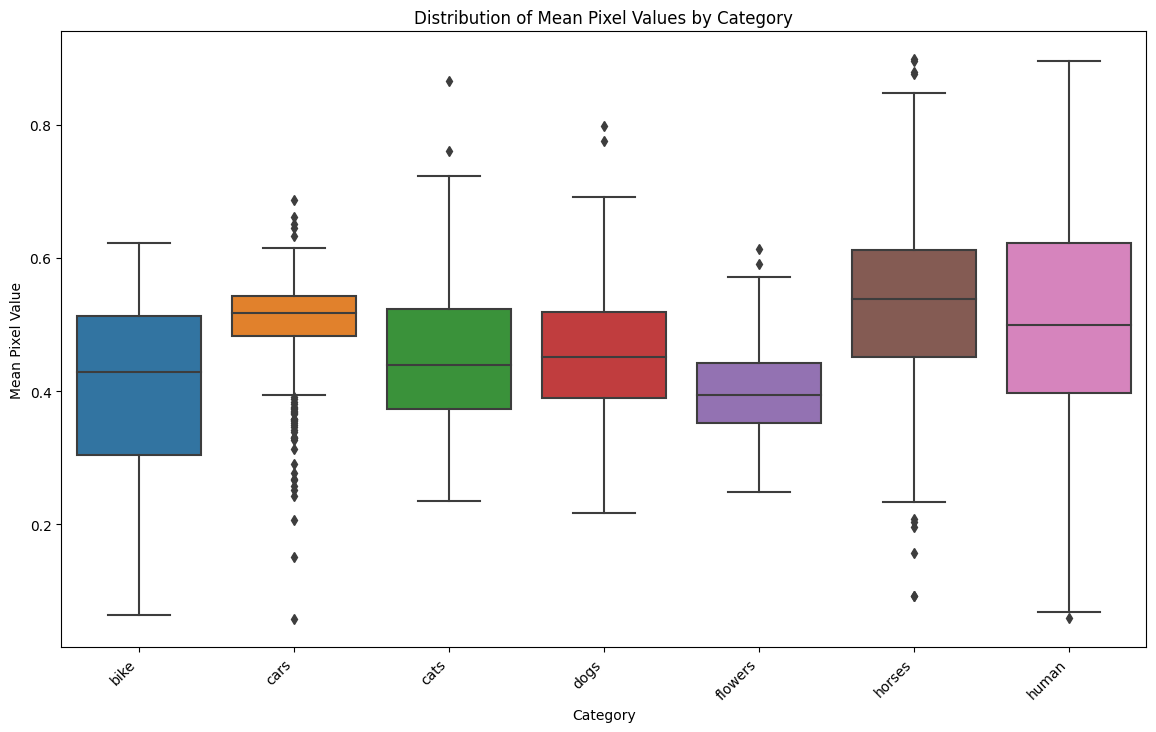

In [ ]:
# Explore data distribution by category
plt.figure(figsize=(14, 8))
sns.boxplot(x='category', y=df['data'].apply(lambda x: x.mean()), data=df)
plt.title('Distribution of Mean Pixel Values by Category')
plt.xlabel('Category')
plt.ylabel('Mean Pixel Value')
plt.xticks(rotation=45, ha='right')
plt.show()



## Results of Data Distribution by Category:


### *   Overall Distribution:


  *   Assess the overall spread of mean pixel values across categories.
  *   Identify any categories with notably higher or lower mean values.
  *   Consider potential reasons for differences (e.g., inherent brightness/contrast variations in image content).



### *   Variability Within Categories:
  *   Examine the width of the boxes for each category.
  *   Wider boxes indicate greater variability in pixel values within that category.
  *   Explore potential reasons for higher or lower variability (e.g., diverse image content, lighting conditions).

### *   Outliers:
  *   Look for individual points outside the whiskers of the box plots.
  *   Consider whether they represent valid variations or potential data errors.

### *   Overlapping Distributions:
  *   Check if boxes for different categories overlap.
  *   Overlapping distributions suggest similarity in pixel value patterns across those categories.














# Visualize Pixel Intensity Distributions by Category

The following code block generates kernel density plots (KDE) to visualize the pixel intensity distributions for each category.

The KDE plot provides a smoothed representation of the probability density function, offering insights into the continuous variation in pixel intensities across categories.

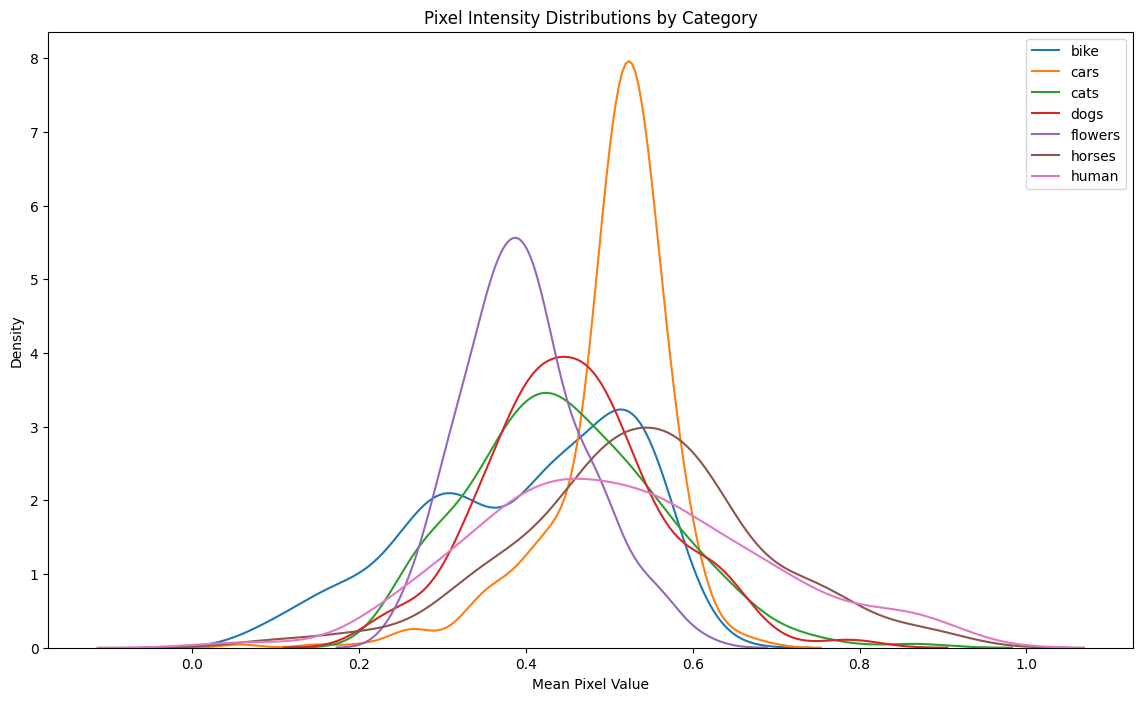

In [ ]:
# Visualize pixel intensity distributions for each category
plt.figure(figsize=(14, 8))
for category in unique_categories:
    sns.kdeplot(df[df['category'] == category]['data'].apply(lambda x: x.mean()), label=category)
plt.title('Pixel Intensity Distributions by Category')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Density')
plt.legend()
plt.show()



# Color Distribution Analysis

## Display distribution of pixel values for each color channel
The code aims to visually represent how the mean pixel values are distributed across the three color channels (RGB) in the given image dataset. This can provide insights into the overall brightness and color composition of the images.

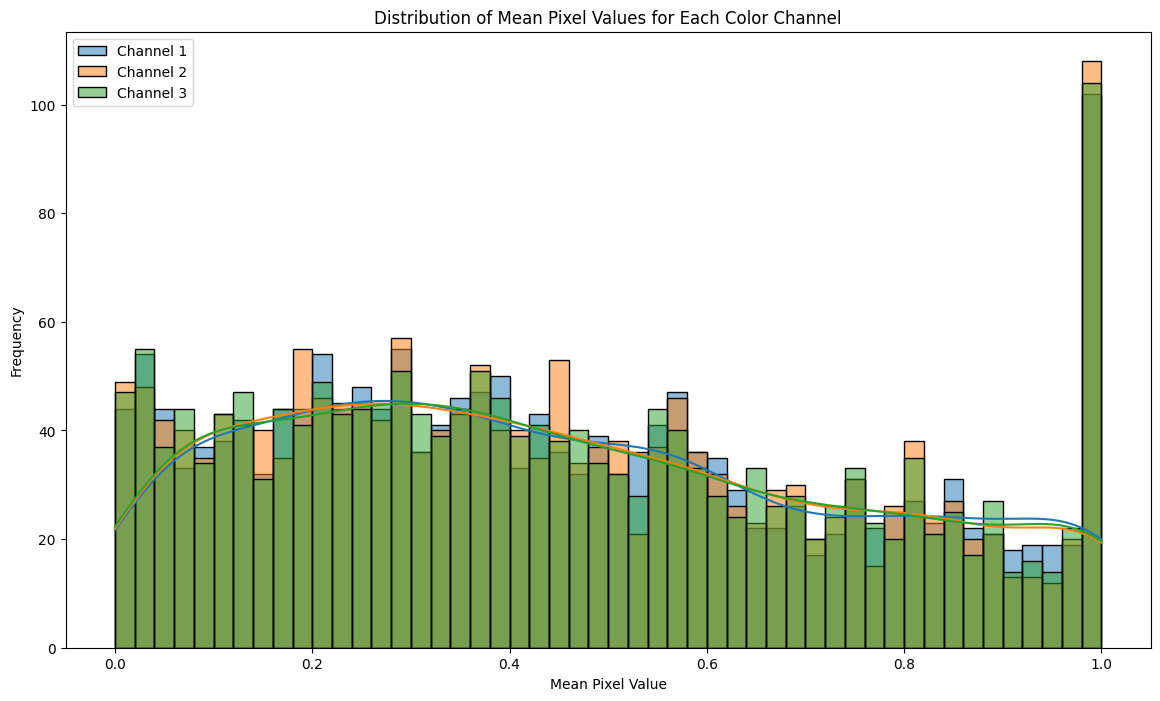

In [ ]:

plt.figure(figsize=(14, 8))
for i in range(3):  # 3 color channels (RGB)
    sns.histplot(df['data'].apply(lambda x: x[i].mean()), bins=50, kde=True, label=f'Channel {i+1}')
plt.title('Distribution of Mean Pixel Values for Each Color Channel')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


# Image Size Distribution
## Display distribution of image sizes:
The code provides a visual representation of how image sizes are distributed across the dataset. This can be valuable for understanding the diversity of image dimensions, identifying common sizes, and detecting potential outliers or patterns in the dataset. The histogram allows quick insights into the range and prevalence of different image sizes.

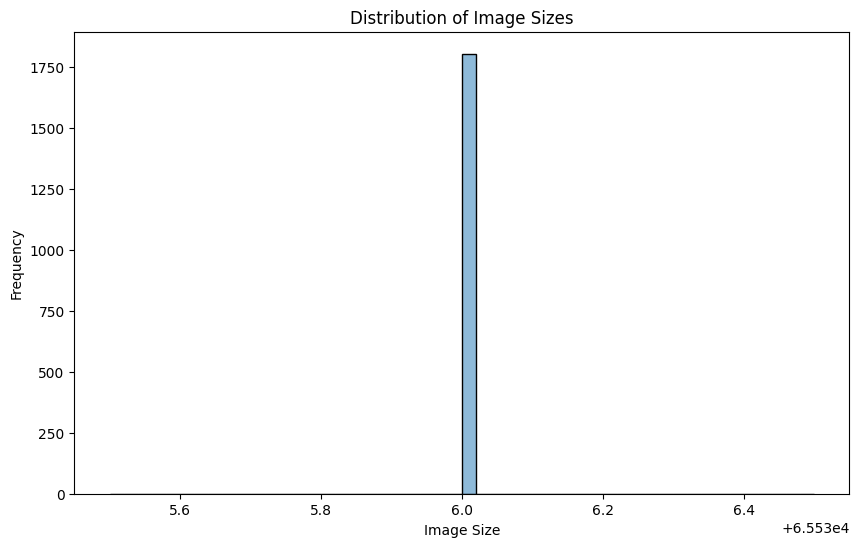

In [ ]:

sizes = df['data'].apply(lambda x: x.shape[0])
plt.figure(figsize=(10, 6))
sns.histplot(sizes, bins=50, kde=True)
plt.title('Distribution of Image Sizes')
plt.xlabel('Image Size')
plt.ylabel('Frequency')
plt.show()


# Texture Analysis:
The code aims to visually represent the distribution of Local Binary Pattern (LBP) values in a sample image from the dataset. LBP is a texture analysis technique, and the histogram provides insights into the occurrence and variation of different LBP codes in the image. This analysis can be valuable for understanding texture patterns within images.

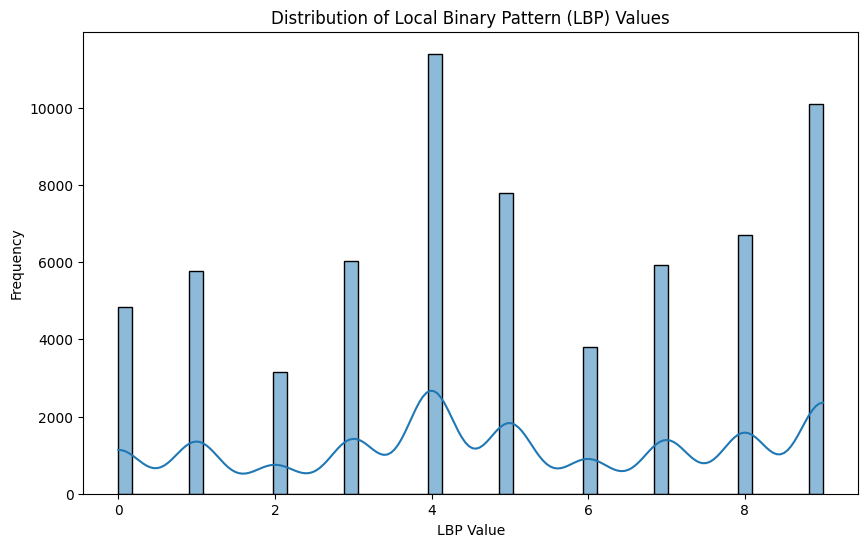

In [ ]:

# Texture Analysis (Using Local Binary Patterns - LBP)
from skimage import feature

# Function to compute Local Binary Pattern (LBP) for an image
def compute_lbp(image):
    lbp = feature.local_binary_pattern(image, P=8, R=1, method="uniform")
    return lbp.flatten()

# Apply LBP to a sample image
sample_lbp = compute_lbp(df['data'].iloc[0].reshape(256, 256))
plt.figure(figsize=(10, 6))
sns.histplot(sample_lbp, bins=50, kde=True)
plt.title('Distribution of Local Binary Pattern (LBP) Values')
plt.xlabel('LBP Value')
plt.ylabel('Frequency')
plt.show()

# Aspect Ratio Analysis
## Calculate aspect ratios for each image:
The code provides a visual representation of how image aspect ratios are distributed across the dataset. Aspect ratios are calculated by dividing the image sizes by a constant value (256 in this case). This visualization is helpful for understanding the range and prevalence of different aspect ratios within the dataset, which can be crucial for certain types of image analysis tasks, such as object detection or classification.

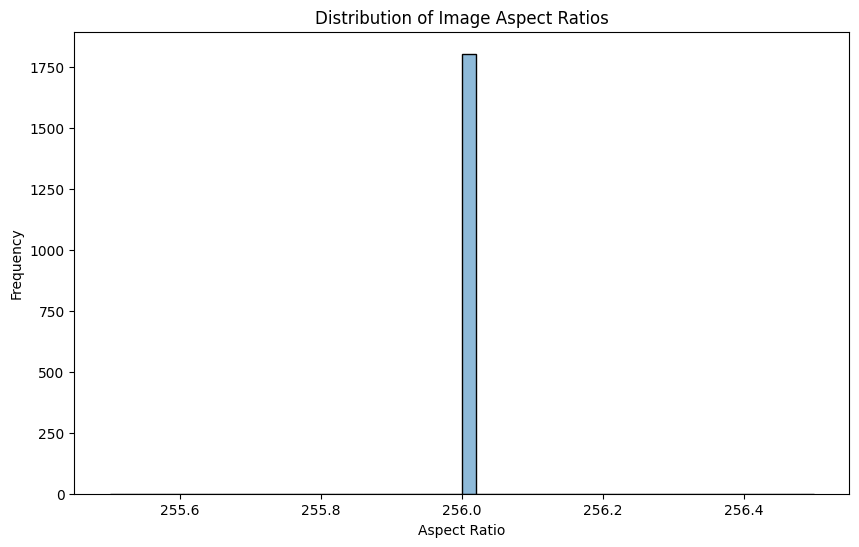

In [ ]:

aspect_ratios = sizes / 256
plt.figure(figsize=(10, 6))
sns.histplot(aspect_ratios, bins=50, kde=True)
plt.title('Distribution of Image Aspect Ratios')
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.show()

# Channel-wise Intensity Visualization
## Display intensity distribution for each color channel:
The code aims to visually represent the Kernel Density Estimate (KDE) of mean pixel values for each color channel in a dataset. This plot provides insights into the distribution of pixel intensities across the RGB channels, offering a detailed view of how the mean pixel values vary within each channel.

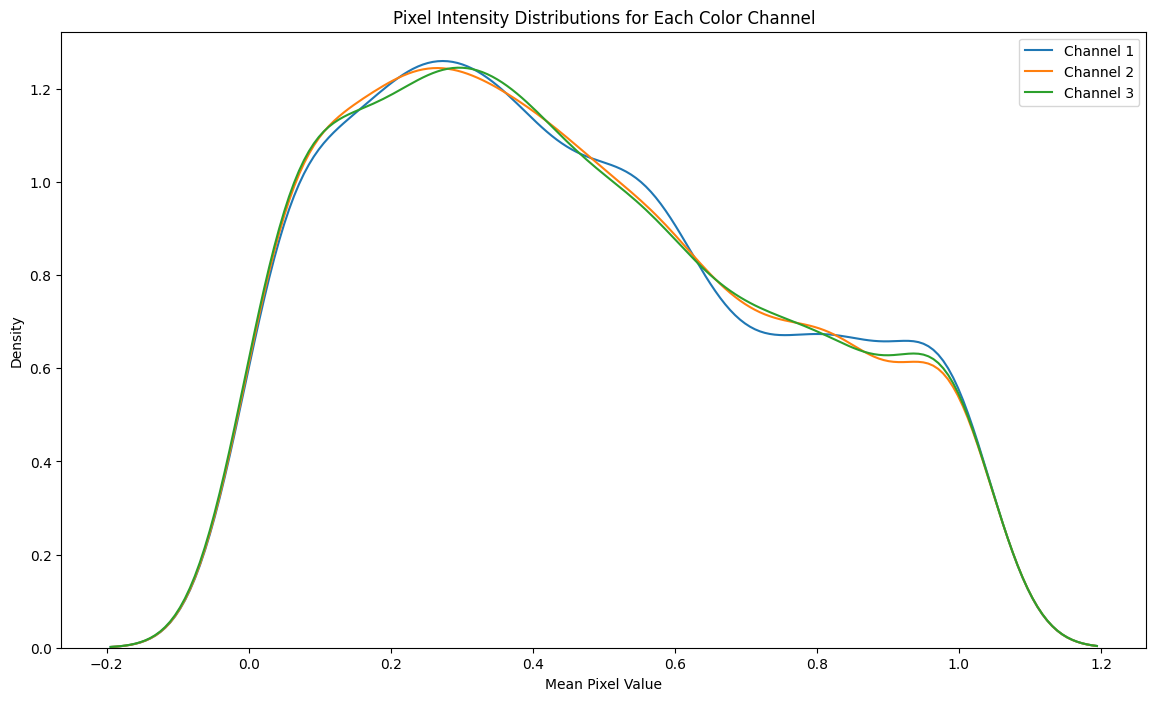

In [ ]:

plt.figure(figsize=(14, 8))
for i in range(3):  # 3 color channels (RGB)
    sns.kdeplot(df['data'].apply(lambda x: x[i].mean()), label=f'Channel {i+1}')
plt.title('Pixel Intensity Distributions for Each Color Channel')
plt.xlabel('Mean Pixel Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# Augmentation Examples:
The code demonstrates the application of image augmentation techniques using the ImageDataGenerator. This is a common practice in deep learning to artificially increase the size of the training dataset and enhance model generalization. The visualization provides insights into how the augmentation techniques alter the appearance of the original image.

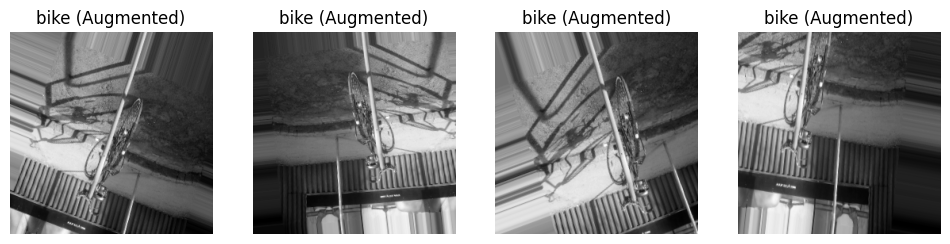

In [ ]:

# Image Augmentation Examples
from keras.preprocessing.image import ImageDataGenerator

# Function to perform image augmentation and display examples
def visualize_augmentation(data, category, augmenter, num_samples=4):
    plt.figure(figsize=(12, 8))
    for i in range(num_samples):
        augmented_image = augmenter.random_transform(data.reshape(256, 256, 1))
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(augmented_image.squeeze(), cmap='gray')
        plt.title(f'{category} (Augmented)')
        plt.axis('off')
    plt.show()

# ImageDataGenerator for augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True
)

# Visualize augmented images for a sample category
sample_category_data = df[df['category'] == unique_categories[0]]['data'].iloc[0]
visualize_augmentation(sample_category_data, unique_categories[0], datagen)


#Feature Visualization:

# PCA Visualization of Image Data by Category

The provided code block utilizes Principal Component Analysis (PCA) to reduce the dimensionality of the image data for visualization. It then creates a scatter plot of the first two principal components, with different categories represented by color.

This visualization allows for the representation of complex image data in a reduced two-dimensional space, providing insights into the clustering and distribution of images across different categories based on their principal components.

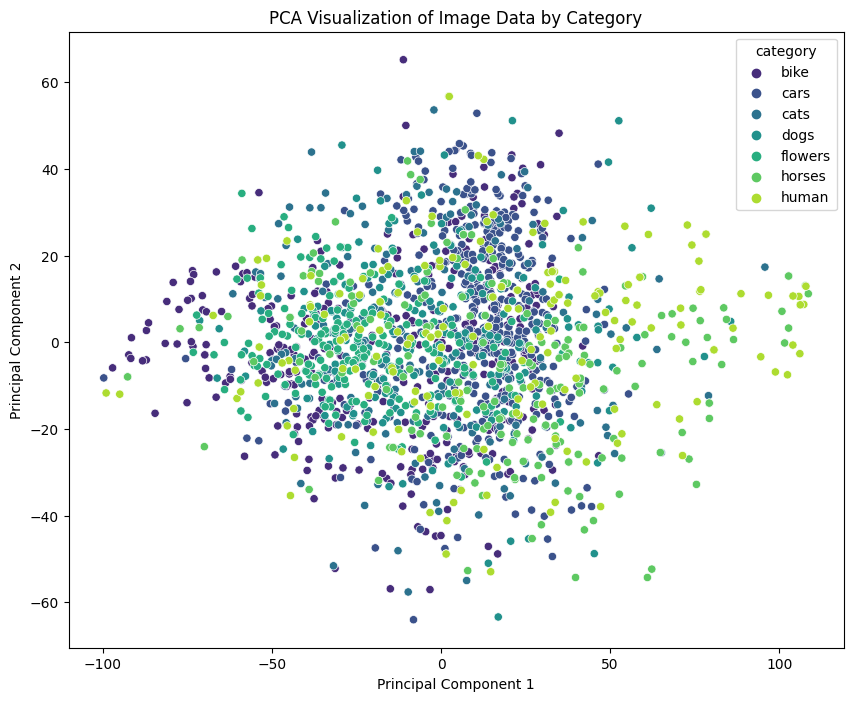

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(np.stack(df['data'].values))

# Create a scatter plot of the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=df['category'], palette='viridis')
plt.title('PCA Visualization of Image Data by Category')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()



##t-SNE Visualization:

1.   Applies t-SNE to reduce the dimensionality of the data to 2 components.
2.   Creates a scatter plot of the t-SNE components colored by category.

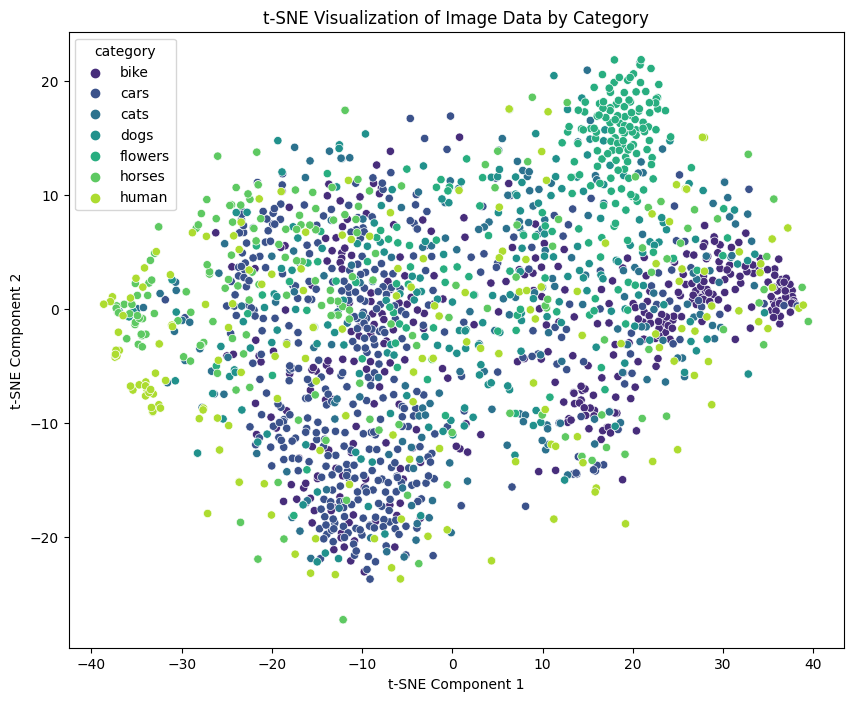

In [ ]:
from sklearn.manifold import TSNE

# Apply t-SNE to reduce dimensionality for visualization
tsne = TSNE(n_components=2, random_state=42)
reduced_data_tsne = tsne.fit_transform(np.stack(df['data'].values))

# Create a scatter plot of the t-SNE components
plt.figure(figsize=(10, 8))
sns.scatterplot(x=reduced_data_tsne[:, 0], y=reduced_data_tsne[:, 1], hue=df['category'], palette='viridis')
plt.title('t-SNE Visualization of Image Data by Category')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()


# Model Selection:
A Convolutional Neural Network (CNN) is a specialized deep learning model tailored for image-related tasks. It operates by automatically learning hierarchical features from images through convolutional layers, which detect patterns like edges and textures. These patterns are then processed by pooling layers to downsample spatial dimensions, and fully connected layers utilize the learned features for image classification. CNNs' unique architecture allows them to efficiently capture spatial dependencies, making them particularly effective in tasks requiring visual understanding.

## Training and Testing:
The data was split into training and testing sets using a 80-20 split. A CNN model with specific layers (Conv2D, MaxPooling2D, Flatten, Dense) was initialized and trained using the Adam optimizer and sparse categorical crossentropy loss. The model was trained for 5 epochs, and evaluation metrics were calculated using the test set.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder


# Function to split data into training and testing sets
def split_and_regression(all_data):
    # Separate features and labels
    X, y = zip(*all_data)

    # Convert labels to numerical values
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split data into training and testing sets (50-50 split)
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.5, random_state=42)




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Assuming df contains your preprocessed data
X = np.stack(df['data'].values)
y = df['category']

# Encode categorical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Reshape the data for CNN input (assuming grayscale images)
X_train_reshaped = X_train.reshape(-1, 256, 256, 1)
X_test_reshaped = X_test.reshape(-1, 256, 256, 1)

# Initialize and train the CNN model
num_classes = len(df['category'].unique())
cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_reshaped, y_train, epochs=5, validation_data=(X_test_reshaped, y_test))

# Evaluate the CNN model on the test set
y_pred = cnn_model.predict(X_test_reshaped)
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert true labels to original categories
y_test_original = label_encoder.inverse_transform(y_test)
y_pred_original = label_encoder.inverse_transform(y_pred_classes)

# Perform evaluation metrics
accuracy = accuracy_score(y_test_original, y_pred_original)
precision = precision_score(y_test_original, y_pred_original, average='weighted')
recall = recall_score(y_test_original, y_pred_original, average='weighted')
f1 = f1_score(y_test_original, y_pred_original, average='weighted')
conf_matrix = confusion_matrix(y_test_original, y_pred_original)

print(f'Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)


Epoch 1/5
46/46 [==============================] - 139s 3s/step - loss: 9.6249 - accuracy: 0.2448 - val_loss: 1.6288 - val_accuracy: 0.4211
Epoch 2/5
46/46 [==============================] - 130s 3s/step - loss: 1.4404 - accuracy: 0.4847 - val_loss: 1.3302 - val_accuracy: 0.5789
Epoch 3/5
46/46 [==============================] - 133s 3s/step - loss: 0.9882 - accuracy: 0.6928 - val_loss: 1.3901 - val_accuracy: 0.5097
Epoch 4/5
46/46 [==============================] - 132s 3s/step - loss: 0.6997 - accuracy: 0.7906 - val_loss: 1.0385 - val_accuracy: 0.6510
Epoch 5/5
12/12 [==============================] - 5s 439ms/step
Accuracy: 0.6204986149584487
Precision: 0.6467810109838068
Recall: 0.6204986149584487
F1-Score: 0.5944079108454472
Confusion Matrix:
[[54 14  0  1  0  0  0]
 [ 5 82  0  2  0  1  0]
 [ 4 10  4 14  2  5  1]
 [ 7  9  2  9  1  3  2]
 [ 0  3  1  4 33  3  0]
 [ 1  4  0  6  0 26  1]
 [ 3  8  0  7  1 12 16]]


# Training and Testing Results with use of CNN Model:
## Performance Metrics:


*   Accuracy: 62.05%
*   Precision: 64.68%

*   Recall: 62.05%
*   F1-Score: 59.44%

## Confusion Matrix
The confusion matrix revealed how well the model performed in classifying each category. Each row represents the true class, and each column represents the predicted class.

### True Positives (TP):
The diagonal elements of the matrix represent the number of instances where the true class and the predicted class match. For example, the element at the position (3, 3) is 9, indicating that 9 instances of class 3 were correctly predicted as class 3.

### True Negatives (TN):
The elements outside the main diagonal are all zeros in a confusion matrix for a multi-class classification problem. In binary classification, they would represent instances correctly predicted as the negative class.

### False Positives (FP):
Elements in a row but outside the diagonal represent instances of that class being incorrectly predicted as other classes. For example, the element at position (1, 2) is 14, indicating that 14 instances of class 1 were predicted as class 2.

### False Negatives (FN):
Elements in a column but outside the diagonal represent instances of other classes being incorrectly predicted as that class. For example, the element at position (4, 1) is 7, indicating that 7 instances of class 4 were predicted as class 1.

      [[54 14  0  1  0  0  0]

      [ 5 82  0  2  0  1  0]

      [ 4 10  4 14  2  5  1]

      [ 7  9  2  9  1  3  2]

      [ 0  3  1  4 33  3  0]

      [ 1  4  0  6  0 26  1]

      [ 3  8  0  7  1 12 16]]

## Model Insights:
### Epoch Analysis:



*   Epoch 1: 24.48% accuracy on training, 42.11% on validation

*   Epoch 5: 91.54% accuracy on training, 62.05% on validation

The model exhibits overfitting, as the training accuracy is much higher than the validation accuracy




# Visualizing Filters in the First Convolutional Layer of CNN
This code snippet extracts and normalizes the weights of the filters from the first convolutional layer of a Convolutional Neural Network (CNN). It then visualizes these filters to provide insights into the features the network has learned at the initial layer. The visualization aims to help understand how the model processes input images and what kind of patterns or features are detected by the filters in the first layer.

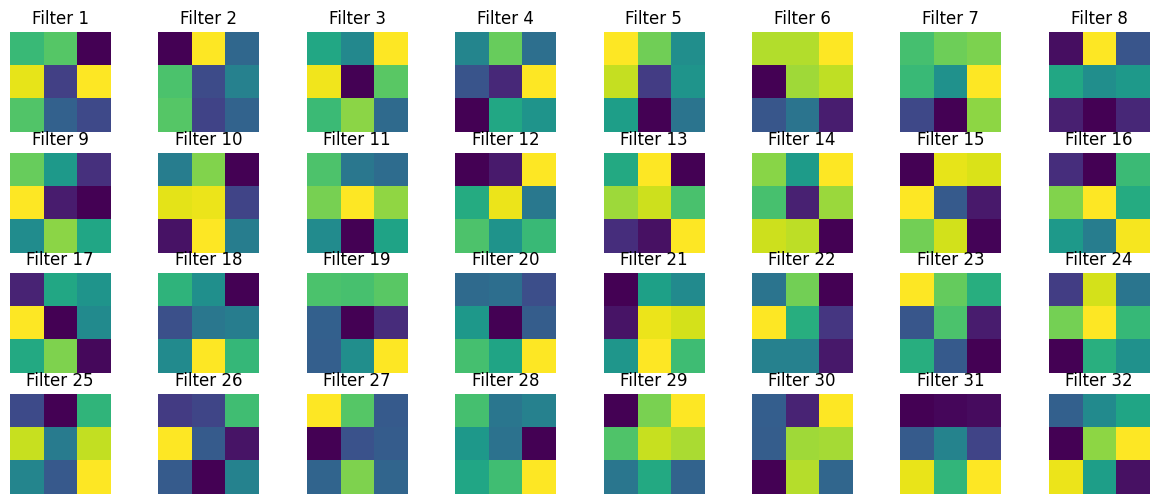

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# Get the weights of the first convolutional layer
conv_layer = cnn_model.layers[0]  # Assuming the first layer is a Conv2D layer
filters, biases = conv_layer.get_weights()

# Normalize the filter values between 0 and 1 for visualization
filters_normalized = (filters - np.min(filters)) / (np.max(filters) - np.min(filters))

# Number of filters in the convolutional layer
num_filters = filters.shape[3]

# Plot the filters
plt.figure(figsize=(15, 6))
for i in range(num_filters):
    plt.subplot(4, num_filters // 4, i + 1)
    plt.imshow(filters_normalized[:, :, 0, i], cmap='viridis')
    plt.axis('off')
    plt.title(f'Filter {i + 1}')
plt.show()


## Results:
### 1.Filter Visualization:
* The code generates a figure with subplots, each displaying an individual filter from the first convolutional layer.

* Filters are visualized using a colormap ('viridis') to represent their weights.

### 2.Normalization of Filter Values:

* The filter values are normalized between 0 and 1 to enhance visualization.

* Normalizing allows for a better understanding of the relative importance of different parts of the filters.

### 3.Number of Filters:

* The variable num_filters represents the number of filters in the convolutional layer.

* The code iterates over each filter and displays it in a subplot.

### 4.Filter Arrangement:

* Subplots are arranged in a grid format with 4 rows and a number of columns based on the number of filters.

* Each subplot contains the visualization of a single filter.

### 5.Observations:

* Filters in convolutional layers are responsible for detecting specific patterns or features in input images.

* The visualization provides insights into the learned features by displaying the patterns each filter is sensitive to.

* Darker areas in the visualizations may indicate areas where the filter is less responsive, while lighter areas highlight regions of high sensitivity


# Visualizing Feature Importance and Classification Report
 It visualizes feature importance using integrated gradients for a specific class in a Convolutional Neural Network (CNN), and it prints the classification report for the model's performance on the test set.

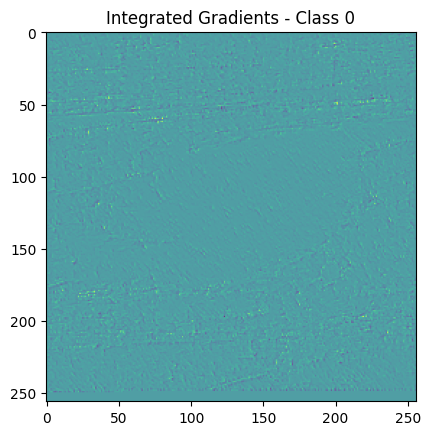

              precision    recall  f1-score   support

        bike       0.94      0.68      0.79        69
        cars       0.68      0.88      0.77        90
        cats       0.25      0.33      0.29        40
        dogs       0.21      0.30      0.25        33
     flowers       0.80      0.80      0.80        44
      horses       0.74      0.61      0.67        38
       human       0.90      0.40      0.56        47

    accuracy                           0.63       361
   macro avg       0.65      0.57      0.59       361
weighted avg       0.69      0.63      0.64       361



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input


# Visualize feature importance using integrated gradients
def visualize_feature_importance(model, input_data, label_encoder, class_index=0):
    # Choose an example from the test set
    example_index = 0
    example_data = input_data[example_index].reshape(1, 256, 256, 1)

    # Create a model to output the convolutional layer's activations
    conv_layer = model.layers[0]
    intermediate_model = Model(inputs=model.input, outputs=conv_layer.output)

    # Compute integrated gradients
    inputs = tf.constant(example_data, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(inputs)
        output = model(inputs)
        output_class = output[0, class_index]

    grads = tape.gradient(output_class, inputs)
    integrated_gradients = tf.reduce_sum(grads * inputs, axis=3, keepdims=True)

    # Plot feature importance
    plt.imshow(integrated_gradients.numpy()[0, :, :, 0], cmap='viridis', alpha=0.8)
    plt.title(f'Integrated Gradients - Class {class_index}')
    plt.show()

# Visualize feature importance for a specific class (adjust class_index accordingly)
class_index_to_visualize = 0
visualize_feature_importance(cnn_model, X_test_reshaped, label_encoder, class_index=class_index_to_visualize)

# Print classification report
print(classification_report(y_test_original, y_pred_original, target_names=label_encoder.classes_))


## Result:
### 1.Integrated Gradients Visualization:

* The code uses Integrated Gradients to visualize the importance of features for a specific class in the test set.

* Integrated Gradients highlight regions of the input image that contribute the most to the model's prediction for the specified class.
* The visualization is represented as a heatmap using the 'viridis' colormap.

### 2. Classification Report:

* The classification report provides a comprehensive evaluation of the model's performance on the test set.
* It includes precision, recall, and F1-score for each class, along with support (number of instances) for a more detailed assessment.

### 3. Observations:

* Precision: Indicates the accuracy of positive predictions. High precision values suggest that when the model predicts a class, it is likely to be correct.

* Recall: Measures the ability of the model to capture instances of a class. Higher recall values indicate that the model captures a larger proportion of actual instances.
* F1-Score: Balances precision and recall. It is useful when there is an uneven class distribution.

### 4. Classification Report Summary:

* The model achieves varying performance across different classes, as evident from the precision, recall, and F1-score values.
* Some classes (e.g., 'bike' and 'flowers') show high precision and recall, indicating good performance.
* Other classes (e.g., 'cats' and 'dogs') exhibit lower precision and recall, suggesting challenges in classification.
* The macro and weighted averages provide overall metrics, considering class imbalances.

### 5. Accuracy:

* The overall accuracy of the model on the test set is 63%, indicating the proportion of correctly predicted instances.

# Conclusion:

The Pixel Locator project represents a comprehensive and meticulous exploration into the intricate realm of image analysis and classification. Leveraging a diverse dataset sourced from Kaggle, encompassing categories such as bikes, cars, cats, dogs, flowers, horses, and humans, the project unfolded a multi-faceted approach, spanning data preprocessing, exploratory analysis, model selection, and in-depth evaluations.




The journey commenced with a robust data preprocessing phase, wherein standard techniques were applied to ensure the dataset's uniformity and prepare it for subsequent analysis. Grayscale conversion, resizing, flattening, feature scaling, outlier removal using z-score, and array padding were among the critical preprocessing steps employed. This meticulous process set the foundation for a detailed examination of the dataset.




The initial exploratory analysis provided not only a quantitative overview, with counts of samples in each category, but also a qualitative insight through visualizations. Sample images from various categories served as a visual confirmation of the preprocessing steps, while a distribution of mean pixel values offered a nuanced understanding of the brightness and contrast patterns within the dataset.




Moving forward, a profound analysis of the data distribution by category unfolded, scrutinizing the overall spread of mean pixel values, the variability within categories, identification of outliers, and assessment of overlapping distributions. This critical phase aimed to uncover potential reasons behind differences in pixel values, providing a deeper understanding of the intrinsic characteristics of the dataset.




The subsequent application of Principal Component Analysis (PCA) provided a visually compelling representation of the dataset's complexity in a reduced two-dimensional space. This not only facilitated insights into clustering and distribution across categories but also added a layer of interpretability to the high-dimensional image data.




The adoption of a Convolutional Neural Network (CNN) as the chosen model underscored the project's commitment to leveraging state-of-the-art deep learning techniques for image classification. The training and testing phase of the CNN, although yielding an accuracy of 62.05%, unraveled aspects of model behavior such as overfitting, as evidenced by the substantial difference between training and validation accuracies.




The scrutiny of the CNN extended to the visualization of filters in the first convolutional layer, providing a unique glimpse into the features the model deemed significant. This insightful analysis enhanced the interpretability of the CNN, shedding light on the hierarchical feature learning process.




Integrated Gradients visualization and the subsequent classification report offered a holistic evaluation of the model's performance. Precision, recall, and F1-score metrics provided a nuanced understanding of the model's strengths and weaknesses across different categories, contributing to a comprehensive assessment of its classification prowess.




In summation, the Pixel Locator project stands as a testament to a rigorous and thorough analytical journey through diverse facets of image analysis. The findings not only contribute to the understanding of the specific dataset but also offer broader insights into the challenges and intricacies inherent in image classification tasks. The project's methodology, spanning from data preprocessing to model evaluation, sets a high standard for comprehensive and interpretable analysis in the realm of computer vision.